# OptionMetrics — Dataset Construction


## Setup
_Run this cell first. It pulls the shared repo code and imports it._


In [ ]:
# === Setup: pull shared code and import (run first) ===
from google.colab import drive; drive.mount('/content/drive')
import os
REPO_URL = 'https://github.com/JosephOuyang/machine_learning_for_implied_volatility_forecasting.git'
REPO_DIR = '/content/repo'
if os.path.isdir(REPO_DIR):
    os.system(f'cd {REPO_DIR} && git pull -q')
else:
    os.system(f'git clone -q {REPO_URL} {REPO_DIR}')
import sys; sys.path.insert(0, REPO_DIR)
from shared.setup import *   # imports, seeds, logger, Drive mount


# OptionMetrics — Dataset Construction


# OptionMetrics

## Dataset Construction (American Equity and European SPX)



In [ ]:
# =========================
# Install WRDS on Colab
# =========================
!pip install wrds

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 103.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 186.8 MB/s eta 0:00:00


In [ ]:
# =========================
# CELL 8a.0 — Week 8a START (OptionMetrics Real Data: 10 Stocks American, 2024)
# =========================
run_dir_w8a, fig_dir_w8a = start_run("week8a_optionmetrics_10stocks_american_2024")
print("run_dir_w8a:", run_dir_w8a)
print("fig_dir_w8a:", fig_dir_w8a)

save_json(run_dir_w8a, "params", {
    "week": "8a",
    "goal": "Build American equity options dataset from OptionMetrics: 10 stocks, full year 2024",
    "data_sources": {
        "option_prices":      "optionm.opprcd",
        "underlying_prices":  "optionm.secprd",
        "zero_curve":         "optionm.zerocd",
        "security_info":      "optionm.securd",
        "exercise_style":     "optionm.opinfd"
    },
    "tickers": ["AAPL", "MSFT", "NVDA", "AMZN", "GOOGL",
                "META", "TSLA", "AMD",  "AVGO", "NFLX"],
    "date_range": {"start": "2024-01-02", "end": "2024-12-31"},
    "filters": {
        "cp_flag":                "C (calls only)",
        "exercise_style":         "A (American only)",
        "min_tau_days":           7,
        "max_tau_days":           365,
        "moneyness_range":        [0.8, 1.2],
        "min_open_interest":      100,
        "min_volume":             1,
        "max_spread_ratio":       0.3,
        "drop_impl_vol_sentinel": -99.99
    },
    "features": ["moneyness", "tau", "r", "impl_volatility", "bs_price"],
    "label":    "mid_price",
    "note": (
        "bs_price is included as a feature because American mid_price is always "
        "strictly greater than the Black-Scholes European price by the early "
        "exercise premium. The MLP uses bs_price as a theoretical lower bound "
        "and learns the correction on top. This is the core motivation from "
        "the professor: American options are more expensive than European options."
    )
})

save_notes(run_dir_w8a, """
Week 8a deliverable:
- Connect to WRDS and pull OptionMetrics data for 10 stocks over full year 2024.
- Pull exercise style from opinfd and merge — confirms all equity options are American.
- Merge option prices with underlying close prices (secprd) on secid + date.
- Interpolate risk-free rate from zero curve (zerocd) for each option row.
- Compute derived columns: tau, moneyness, mid_price, strike (divide by 1000), bs_price.
- Apply liquidity and quality filters per professor's guidance.
- Final dataframe columns: ticker, secid, date, exdate, cp_flag, exercise_style,
  close, strike, tau, r, impl_volatility, bs_price, mid_price, moneyness,
  volume, open_interest.
- Save final dataset as CSV.
- EDA: distributions of all features, row counts before/after filtering, per-ticker breakdown.
""")

print("Week 8a logger ready ✅")

run_dir_w8a: runs/week8a_optionmetrics_10stocks_american_2024/20260416-222959
fig_dir_w8a: runs/week8a_optionmetrics_10stocks_american_2024/20260416-222959/figures
Week 8a logger ready ✅


In [ ]:
# =========================
# CELL 8a.1 — Imports and WRDS Connection
# =========================
import wrds
import pandas as pd
import numpy as np
from scipy.stats import norm
import matplotlib.pyplot as plt
import os

db = wrds.Connection(wrds_username='your_username')
print("WRDS connection established ✅")

Enter your WRDS username [your_username]:calebouy
Enter your password:··········
WRDS recommends setting up a .pgpass file.
Create .pgpass file now [y/n]?: y
Created .pgpass file successfully.
You can create this file yourself at any time with the create_pgpass_file() function.
Loading library list...
Done
WRDS connection established ✅


In [ ]:
# =========================
# CELL 8a.2 — Look Up secid for Each Ticker
# =========================

# IvyDB uses secid as its permanent identifier, not ticker.
# Tickers can change over a company's lifetime; secid never does.
# index_flag = '0' means it is an equity (not an index).

TICKERS = ['AAPL', 'MSFT', 'NVDA', 'AMZN', 'GOOGL',
           'META', 'TSLA', 'AMD',  'AVGO', 'NFLX']

ticker_str = ", ".join(f"'{t}'" for t in TICKERS)

secur = db.raw_sql(f"""
    SELECT secid, ticker
    FROM optionm.securd
    WHERE ticker IN ({ticker_str})
    AND index_flag = '0'
""")

print("Security lookup result:")
print(secur)

# Sanity check: we expect exactly 10 rows
assert len(secur) == 10, (
    f"Expected 10 secids, got {len(secur)}. "
    "Check for duplicate tickers or missing entries."
)

ticker_to_secid = dict(zip(secur['ticker'], secur['secid']))
secid_to_ticker = dict(zip(secur['secid'], secur['ticker']))
secid_list       = secur['secid'].tolist()
secid_str        = ', '.join(str(s) for s in secid_list)

print("\nticker -> secid mapping:")
for t, s in ticker_to_secid.items():
    print(f"  {t}: {s}")

save_json(run_dir_w8a, "ticker_secid_mapping", ticker_to_secid)
print("\nMapping saved ✅")

Security lookup result:
      secid ticker
0  101594.0   AAPL
1  101121.0    AMD
2  101310.0   AMZN
3  139322.0   AVGO
4  121812.0  GOOGL
5  154402.0   META
6  107525.0   MSFT
7  115422.0   NFLX
8  108321.0   NVDA
9  143439.0   TSLA

ticker -> secid mapping:
  AAPL: 101594.0
  AMD: 101121.0
  AMZN: 101310.0
  AVGO: 139322.0
  GOOGL: 121812.0
  META: 154402.0
  MSFT: 107525.0
  NFLX: 115422.0
  NVDA: 108321.0
  TSLA: 143439.0

Mapping saved ✅


In [ ]:
# =========================
# CELL 8a.3 — Pull Option Prices (opprcd)
# =========================

# opprcd is the main Option Price file.
# strike_price is stored as actual strike * 1000 (IvyDB convention).
# impl_volatility = -99.99 is OptionMetrics sentinel for failed IV calculation.
# We pre-filter best_bid > 0 and impl_volatility > 0 to reduce pull size.

DATE_START = '2024-01-02'
DATE_END   = '2024-12-31'

options = db.raw_sql(f"""
    SELECT secid, date, exdate, cp_flag,
           strike_price, best_bid, best_offer,
           volume, open_interest, impl_volatility
    FROM optionm.opprcd2024
    WHERE secid IN ({secid_str})
    AND date BETWEEN '{DATE_START}' AND '{DATE_END}'
    AND cp_flag = 'C'
    AND best_bid > 0
    AND impl_volatility > 0
    AND impl_volatility != -99.99
""")

print(f"Option rows pulled: {len(options):,}")
options.head()

Option rows pulled: 4,088,646


,secid,date,exdate,cp_flag,strike_price,best_bid,best_offer,volume,open_interest,impl_volatility
0,101121.0,2024-01-12,2024-12-20,C,105000.0,51.85,54.55,0.0,0.0,0.492853
1,101121.0,2024-01-12,2024-12-20,C,110000.0,48.25,50.7,0.0,0.0,0.481273
2,101121.0,2024-01-12,2024-12-20,C,115000.0,44.9,45.9,0.0,0.0,0.458308
3,101121.0,2024-01-02,2024-01-05,C,100000.0,38.65,38.85,25.0,134.0,1.73292
4,101121.0,2024-01-02,2024-01-05,C,101000.0,37.65,37.8,4.0,12.0,1.631948


In [ ]:
# =========================
# CELL 8a.4 — Pull Underlying Close Prices (secprd)
# =========================

# secprd contains the daily close price for each underlying security.
# We merge this with the options data on secid + date to get S (spot price).

prices = db.raw_sql(f"""
    SELECT secid, date, close
    FROM optionm.secprd2024
    WHERE secid IN ({secid_str})
    AND date BETWEEN '{DATE_START}' AND '{DATE_END}'
""")

print(f"Underlying price rows pulled: {len(prices):,}")
prices.head()

Underlying price rows pulled: 2,520


,secid,date,close
0,101121.0,2024-01-02,138.58
1,101121.0,2024-01-03,135.32
2,101121.0,2024-01-04,136.01
3,101121.0,2024-01-05,138.58
4,101121.0,2024-01-08,146.18


In [ ]:
# =========================
# CELL 8a.5 — Pull Zero Curve (zerocd)
# =========================

# zerocd contains continuously compounded zero-coupon rates
# by date and days-to-maturity.
# We interpolate from this table to get r for each option row.
# Note: as of Dec 2021, OptionMetrics switched from LIBOR to
# SOFR-based implied risk-free rates. All 2024 data uses this methodology.

zero_curve = db.raw_sql(f"""
    SELECT date, days, rate
    FROM optionm.zerocd
    WHERE date BETWEEN '{DATE_START}' AND '{DATE_END}'
""")

zero_curve['date'] = pd.to_datetime(zero_curve['date'])
print(f"Zero curve rows pulled: {len(zero_curve):,}")
zero_curve.head()

Zero curve rows pulled: 2,772


,date,days,rate
0,2024-01-02,10.0,5.331048
1,2024-01-02,30.0,5.351727
2,2024-01-02,60.0,5.377562
3,2024-01-02,91.0,5.397942
4,2024-01-02,122.0,5.412153


In [ ]:
# =========================
# CELL 8a.5b — Pull Exercise Style (opinfd) and Merge into Options
# =========================

# opinfd contains one row per secid with the exercise style:
# 'A' = American, 'E' = European.
# For US-listed individual equity options, all should be 'A'.
# We merge this in so we can filter explicitly and document it.
# (Confirmed: these 10 equity tickers have no European-style options.)

opinf = db.raw_sql(f"""
    SELECT secid, exercise_style
    FROM optionm.opinfd
    WHERE secid IN ({secid_str})
""")

print("Exercise styles found:")
print(opinf)

options['date']   = pd.to_datetime(options['date'])
options['exdate'] = pd.to_datetime(options['exdate'])

options = options.merge(
    opinf[['secid', 'exercise_style']],
    on='secid',
    how='left'
)

print("\nExercise style counts after merge:")
print(options['exercise_style'].value_counts())

Exercise styles found:
      secid exercise_style
0  101121.0              A
1  101310.0              A
2  101594.0              A
3  107525.0              A
4  108321.0              A
5  115422.0              A
6  121812.0              A
7  139322.0              A
8  143439.0              A
9  154402.0              A

Exercise style counts after merge:
exercise_style
A    4088646
Name: count, dtype: Int64


In [ ]:
# =========================
# CELL 8a.6 — Merge Options with Underlying Prices
# =========================

prices['date'] = pd.to_datetime(prices['date'])

df = options.merge(
    prices[['secid', 'date', 'close']],
    on=['secid', 'date'],
    how='left'
)

missing_close = df['close'].isna().sum()
print(f"Rows after merge:         {len(df):,}")
print(f"Rows missing close price: {missing_close:,}")

df = df.dropna(subset=['close'])
print(f"Rows after dropping missing close: {len(df):,}")

Rows after merge:         4,088,646
Rows missing close price: 0
Rows after dropping missing close: 4,088,646


In [ ]:
# =========================
# CELL 8a.7 — Compute Derived Columns (tau, moneyness, strike, mid_price)
# =========================

# Strike: IvyDB stores as actual_strike * 1000, so divide by 1000
df['strike'] = df['strike_price'] / 1000

# Tau: time to expiry in years
df['tau'] = (df['exdate'] - df['date']).dt.days / 365.0

# Days to expiry as integer (used for zero curve interpolation)
df['days_to_expiry'] = (df['exdate'] - df['date']).dt.days

# Moneyness: S / K
df['moneyness'] = df['close'] / df['strike']

# Mid price: actual observed market price — this is the label
df['mid_price'] = (df['best_bid'] + df['best_offer']) / 2

print("Derived columns computed ✅")
print(df[['strike', 'tau', 'moneyness', 'mid_price']].describe())

Derived columns computed ✅
           strike           tau  moneyness   mid_price
count   4088646.0  4.088646e+06  4088646.0   4088646.0
mean   420.868744  6.993832e-01   1.988084  112.844144
std    388.117111  6.941368e-01   6.470772  164.663868
min           0.5  2.739726e-03   0.193913        0.01
25%         148.0  1.150685e-01   0.801581        9.65
50%         280.0  4.602740e-01   1.073782        50.6
75%         580.0  1.095890e+00     1.6177       133.3
max        2750.0  2.953425e+00     297.76      1610.3


In [ ]:
# =========================
# CELL 8a.8 — Interpolate Risk-Free Rate from Zero Curve
# =========================

# Pre-group by date so we are not re-filtering on every row
zero_grouped = {
    date: group.sort_values('days')
    for date, group in zero_curve.groupby('date')
}

def get_rate(option_date, days):
    """
    Linearly interpolate the zero-coupon rate for a given date
    and days-to-expiry from the IvyDB zero curve.

    Example: if the curve has 30-day rate = 0.043 and 60-day rate = 0.045,
    and your option expires in 45 days:
      weight = (45 - 30) / (60 - 30) = 0.5
      rate   = 0.043 + 0.5 * (0.045 - 0.043) = 0.044
    """
    if option_date not in zero_grouped:
        return np.nan

    curve  = zero_grouped[option_date]
    zdays  = curve['days'].values
    zrates = curve['rate'].values

    if len(zdays) < 2:
        return np.nan

    # Outside the curve range: use nearest endpoint
    if days <= zdays[0]:
        return float(zrates[0])
    if days >= zdays[-1]:
        return float(zrates[-1])

    # Find the two neighboring points
    idx       = np.searchsorted(zdays, days)
    days_low  = zdays[idx - 1]
    days_high = zdays[idx]
    rate_low  = zrates[idx - 1]
    rate_high = zrates[idx]

    # Straight line between the two neighbors evaluated at days
    weight = (days - days_low) / (days_high - days_low)
    return float(rate_low + weight * (rate_high - rate_low))

df['r'] = df.apply(
    lambda row: get_rate(row['date'], row['days_to_expiry']),
    axis=1
)

# Convert from percent to decimal
# zerocd stores rates in percent (e.g. 5.21 means 5.21%)
# Black-Scholes and all downstream formulas require decimal (e.g. 0.0521)
df['r'] = df['r'] / 100

missing_r = df['r'].isna().sum()
print(f"Rows missing r after interpolation: {missing_r:,}")
print(f"r range after conversion: {df['r'].min():.6f} to {df['r'].max():.6f}")
print("Expected range: ~0.045 to ~0.056")

Rows missing r after interpolation: 0
r range after conversion: 0.039416 to 0.056125
Expected range: ~0.045 to ~0.056


In [ ]:
# =========================
# CELL 8a.9 — Compute Black-Scholes Price as Feature (vectorized)
# =========================

# r is already in decimal form after the /100 fix in CELL 8a.8.
# Do NOT divide by 100 again here — it is already correct.

mask = (df['tau'] > 0) & (df['impl_volatility'] > 0)

S     = df.loc[mask, 'close'].values
K     = df.loc[mask, 'strike'].values
tau   = df.loc[mask, 'tau'].values
r     = df.loc[mask, 'r'].values        # already decimal from CELL 8a.8
sigma = df.loc[mask, 'impl_volatility'].values

d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * tau) / (sigma * np.sqrt(tau))
d2 = d1 - sigma * np.sqrt(tau)

bs_vals = S * norm.cdf(d1) - K * np.exp(-r * tau) * norm.cdf(d2)

df['bs_price'] = np.nan
df.loc[mask, 'bs_price'] = bs_vals

# For rows where tau <= 0 or sigma <= 0, use intrinsic value
df.loc[~mask, 'bs_price'] = np.maximum(
    df.loc[~mask, 'close'] - df.loc[~mask, 'strike'], 0
)

print("BS prices computed ✅")
print(df[['mid_price', 'bs_price']].describe())

# Sanity check: bs_price mean should be in the same ballpark as mid_price mean
# If bs_price mean is wildly different, r unit is still wrong
bs_mean  = df['bs_price'].mean()
mid_mean = df['mid_price'].mean()
print(f"\nSanity check:")
print(f"  bs_price mean:  ${bs_mean:.2f}")
print(f"  mid_price mean: ${mid_mean:.2f}")
print(f"  American calls: mid_price should be >= bs_price (early exercise premium)")

BS prices computed ✅
        mid_price      bs_price
count   4088646.0  4.088646e+06
mean   112.844144  1.137557e+02
std    164.663868  1.659529e+02
min          0.01  1.000609e-02
25%          9.65  9.774885e+00
50%          50.6  5.109886e+01
75%         133.3  1.343511e+02
max        1610.3  1.618190e+03

Sanity check:
  bs_price mean:  $113.76
  mid_price mean: $112.84
  American calls: mid_price should be >= bs_price (early exercise premium)


In [ ]:
# =========================
# CELL 8a.10 — Liquidity and Quality Filters
# =========================

# Per professor's guidance: illiquid options have unrealistic prices
# that will confuse the MLP. These filters keep only the well-traded,
# reliable core of the dataset.

rows_before = len(df)
filter_log  = {}

def drop_and_log(df, mask, label, filter_log):
    before = len(df)
    df = df[mask]
    filter_log[label] = before - len(df)
    return df

# Keep American exercise style only
# (all 10 equity tickers confirmed to be American, but explicit is better)
df = drop_and_log(df, df['exercise_style'] == 'A',
                  'drop_non_american', filter_log)

# Drop failed IV calculations (OptionMetrics sentinel value)
df = drop_and_log(df, df['impl_volatility'] != -99.99,
                  'drop_iv_sentinel', filter_log)

# Minimum 7 days to expiry (avoid gamma explosion near expiration)
df = drop_and_log(df, df['tau'] >= 7 / 365,
                  'drop_short_tau', filter_log)

# Maximum 1 year to expiry (illiquid beyond this)
df = drop_and_log(df, df['tau'] <= 1.0,
                  'drop_long_tau', filter_log)

# Near-the-money only: moneyness between 0.8 and 1.2
df = drop_and_log(df, df['moneyness'].between(0.8, 1.2),
                  'drop_moneyness', filter_log)

# Must have traded on that day
df = drop_and_log(df, df['volume'] > 0,
                  'drop_zero_volume', filter_log)

# Minimum open interest of 100 contracts
df = drop_and_log(df, df['open_interest'] >= 100,
                  'drop_low_oi', filter_log)

# Valid mid price
df = drop_and_log(df, df['mid_price'] > 0,
                  'drop_zero_mid', filter_log)

# Bid-ask spread ratio <= 0.3 (wide spreads signal illiquid options)
spread_ratio = (df['best_offer'] - df['best_bid']) / df['mid_price']
df = drop_and_log(df, spread_ratio <= 0.3,
                  'drop_wide_spread', filter_log)

# Drop rows where r or bs_price is missing
df = drop_and_log(df, df['r'].notna() & df['bs_price'].notna(),
                  'drop_missing_r_or_bs', filter_log)

rows_after = len(df)

print(f"Rows before filtering: {rows_before:,}")
print(f"Rows after filtering:  {rows_after:,}")
print(f"Rows removed:          {rows_before - rows_after:,}")
print("\nFilter breakdown:")
for fname, count in filter_log.items():
    print(f"  {fname}: {count:,}")

save_json(run_dir_w8a, "filter_log", {
    "rows_before": rows_before,
    "rows_after":  rows_after,
    **{k: int(v) for k, v in filter_log.items()}
})

Rows before filtering: 4,088,646
Rows after filtering:  642,614
Rows removed:          3,446,032

Filter breakdown:
  drop_non_american: 0
  drop_iv_sentinel: 0
  drop_short_tau: 114,411
  drop_long_tau: 1,127,355
  drop_moneyness: 1,819,990
  drop_zero_volume: 178,049
  drop_low_oi: 190,437
  drop_zero_mid: 0
  drop_wide_spread: 15,790
  drop_missing_r_or_bs: 0


In [ ]:
# =========================
# CELL 8a.11 — Add Ticker Column and Select Final Columns
# =========================

df['ticker'] = df['secid'].map(secid_to_ticker)

FINAL_COLS = [
    'ticker',          # which stock
    'secid',           # OptionMetrics permanent ID
    'date',            # observation date
    'exdate',          # expiration date
    'cp_flag',         # C = call
    'exercise_style',  # A = American (confirmed for all rows)
    'close',           # underlying stock price S
    'strike',          # strike price K (already divided by 1000)
    'tau',             # time to expiry in years
    'r',               # interpolated risk-free rate from zerocd
    'impl_volatility', # sigma (CRR-implied vol from OptionMetrics)
    'bs_price',        # Black-Scholes theoretical price (feature / lower bound)
    'mid_price',       # actual observed market price (label)
    'moneyness',       # S / K
    'volume',
    'open_interest',
]

df_final = df[FINAL_COLS].reset_index(drop=True)

print("Final dataset shape:", df_final.shape)
print("\nColumn dtypes:")
print(df_final.dtypes)
print("\nSample rows:")
display(df_final.head(10))

Final dataset shape: (642614, 16)

Column dtypes:
ticker                     object
secid                     Float64
date               datetime64[ns]
exdate             datetime64[ns]
cp_flag            string[python]
exercise_style     string[python]
close                     Float64
strike                    Float64
tau                       float64
r                         float64
impl_volatility           Float64
bs_price                  float64
mid_price                 Float64
moneyness                 Float64
volume                    Float64
open_interest             Float64
dtype: object

Sample rows:


,ticker,secid,date,exdate,cp_flag,exercise_style,close,strike,tau,r,impl_volatility,bs_price,mid_price,moneyness,volume,open_interest
0,AMD,101121.0,2024-01-02,2024-01-12,C,A,138.58,117.0,0.027397,0.05331,0.602047,21.975017,21.975,1.184444,14.0,186.0
1,AMD,101121.0,2024-01-02,2024-01-12,C,A,138.58,118.0,0.027397,0.05331,0.588705,20.999984,21.0,1.174407,3.0,142.0
2,AMD,101121.0,2024-01-02,2024-01-12,C,A,138.58,120.0,0.027397,0.05331,0.548185,19.025009,19.025,1.154833,8.0,366.0
3,AMD,101121.0,2024-01-02,2024-01-12,C,A,138.58,121.0,0.027397,0.05331,0.541982,18.075090,18.075,1.145289,14.0,140.0
4,AMD,101121.0,2024-01-02,2024-01-12,C,A,138.58,123.0,0.027397,0.05331,0.50608,16.125025,16.125,1.126667,9.0,277.0
5,AMD,101121.0,2024-01-02,2024-01-12,C,A,138.58,124.0,0.027397,0.05331,0.486906,15.150022,15.15,1.117581,26.0,183.0
6,AMD,101121.0,2024-01-02,2024-01-12,C,A,138.58,125.0,0.027397,0.05331,0.480965,14.225014,14.225,1.10864,31.0,953.0
7,AMD,101121.0,2024-01-02,2024-01-12,C,A,138.58,126.0,0.027397,0.05331,0.459392,13.249957,13.25,1.099841,2.0,417.0
8,AMD,101121.0,2024-01-02,2024-01-12,C,A,138.58,127.0,0.027397,0.05331,0.449019,12.324990,12.325,1.091181,17.0,185.0
9,AMD,101121.0,2024-01-02,2024-01-12,C,A,138.58,128.0,0.027397,0.05331,0.441507,11.425087,11.425,1.082656,206.0,115.0


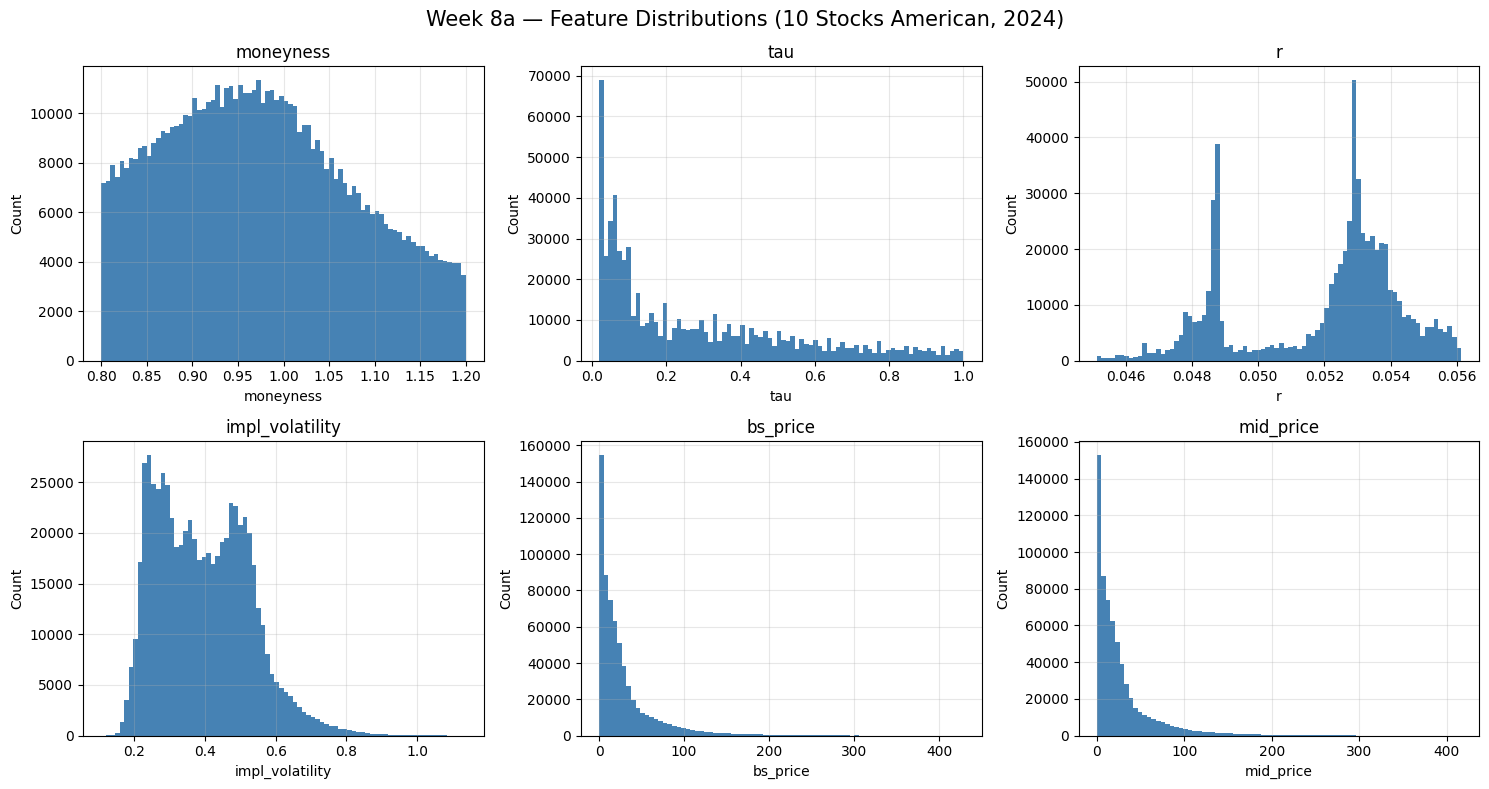

Saved: runs/week8a_optionmetrics_10stocks_american_2024/20260416-222959/figures/week8a_feature_distributions.png


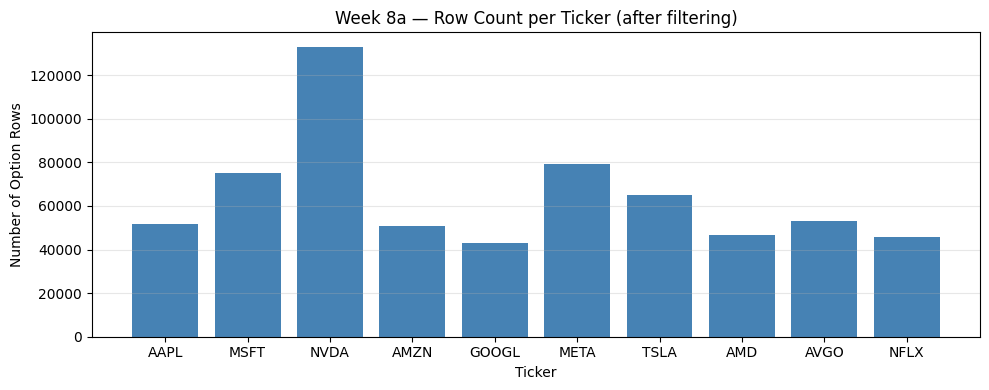

Saved: runs/week8a_optionmetrics_10stocks_american_2024/20260416-222959/figures/week8a_rows_per_ticker.png

Per-ticker statistics:


,rows,mean_tau,mean_moneyness,mean_iv,mean_mid,mean_bs
ticker,,,,,,
AAPL,51713,0.3200,0.977,0.2447,11.7131,11.8837
AMD,46517,0.2697,0.9708,0.4808,13.735,13.7432
AMZN,50953,0.3070,0.9753,0.3196,12.5152,12.5238
AVGO,52919,0.2512,0.9754,0.4221,38.0415,38.9644
GOOGL,42843,0.3073,0.9781,0.2902,10.1917,10.2900
META,79164,0.2664,0.9752,0.3674,35.5966,35.8962
MSFT,74989,0.3256,0.974,0.2449,22.8264,23.3080
NFLX,45616,0.2212,0.9809,0.3496,41.4182,41.4572
NVDA,133034,0.2825,0.982,0.5165,41.7347,41.7763


Saved: runs/week8a_optionmetrics_10stocks_american_2024/20260416-222959/week8a_ticker_stats.csv


In [ ]:
# =========================
# CELL 8a.12 — EDA: Feature Distributions and Per-Ticker Breakdown
# =========================

# --- Plot 1: Histograms of all numeric features ---
feature_cols = ['moneyness', 'tau', 'r', 'impl_volatility', 'bs_price', 'mid_price']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Week 8a — Feature Distributions (10 Stocks American, 2024)", fontsize=15)

for i, col in enumerate(feature_cols):
    ax = axes[i // 3][i % 3]
    ax.hist(df_final[col], bins=80, color='steelblue', edgecolor='none')
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Count")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
hist_path = os.path.join(fig_dir_w8a, "week8a_feature_distributions.png")
plt.savefig(hist_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", hist_path)

# --- Plot 2: Row count per ticker ---
ticker_counts = df_final['ticker'].value_counts().reindex(TICKERS).fillna(0).astype(int)

plt.figure(figsize=(10, 4))
plt.bar(ticker_counts.index, ticker_counts.values, color='steelblue')
plt.xlabel("Ticker")
plt.ylabel("Number of Option Rows")
plt.title("Week 8a — Row Count per Ticker (after filtering)")
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()

ticker_bar_path = os.path.join(fig_dir_w8a, "week8a_rows_per_ticker.png")
plt.savefig(ticker_bar_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", ticker_bar_path)

# --- Per-ticker stats table ---
ticker_stats = df_final.groupby('ticker').agg(
    rows           = ('mid_price',       'count'),
    mean_tau       = ('tau',             'mean'),
    mean_moneyness = ('moneyness',       'mean'),
    mean_iv        = ('impl_volatility', 'mean'),
    mean_mid       = ('mid_price',       'mean'),
    mean_bs        = ('bs_price',        'mean'),
).round(4)

print("\nPer-ticker statistics:")
display(ticker_stats)

ticker_stats_path = os.path.join(run_dir_w8a, "week8a_ticker_stats.csv")
ticker_stats.to_csv(ticker_stats_path)
print("Saved:", ticker_stats_path)

In [ ]:
# =========================
# CELL 8a.13 — Save Final Dataset
# =========================

csv_path_w8a = os.path.join(run_dir_w8a, "options_10stocks_american_2024.csv")
df_final.to_csv(csv_path_w8a, index=False)
print(f"Saved final dataset to: {csv_path_w8a}")
print(f"Shape: {df_final.shape}")

save_json(run_dir_w8a, "dataset_summary", {
    "rows":            int(len(df_final)),
    "tickers":         TICKERS,
    "date_range":      {"start": DATE_START, "end": DATE_END},
    "columns":         FINAL_COLS,
    "rows_per_ticker": ticker_counts.to_dict(),
})

Saved final dataset to: runs/week8a_optionmetrics_10stocks_american_2024/20260416-222959/options_10stocks_american_2024.csv
Shape: (642614, 16)


In [ ]:
# =========================
# CELL 8a.14 — Week 8a Summary
# =========================

summary_text = f"""
WEEK 8a SUMMARY — OptionMetrics Real Data: 10 Stocks American, 2024

Goal:
Build the American equity options dataset from OptionMetrics for training an MLP.
This transitions the project from synthetic Black-Scholes data to observed
market prices, focusing on the early exercise premium as the key learning signal.

Data Sources:
- Option prices:       optionm.opprcd
- Underlying prices:   optionm.secprd
- Risk-free rates:     optionm.zerocd (zero curve, interpolated per row)
- Exercise style:      optionm.opinfd (confirmed all American for equity tickers)
- Security lookup:     optionm.securd

Tickers: {', '.join(TICKERS)}
Date range: {DATE_START} to {DATE_END}

Why bs_price is included as a feature:
- American mid_price is always >= Black-Scholes European price.
- The gap is the early exercise premium — structured and learnable.
- bs_price gives the MLP a theoretical lower bound anchor.
- The MLP learns the correction (early exercise premium) on top.
- Professor motivation: American options are more expensive than European options.

Dataset Construction:
- Pulled exercise style from opinfd and merged on secid.
  Confirmed: all 10 equity tickers have exercise_style = 'A' (American).
- Merged option prices with underlying close prices on secid + date.
- Interpolated risk-free rate from zero curve (linear interpolation).
- Computed: tau, moneyness, mid_price, strike (divided by 1000), bs_price.
- Note: strike_price in opprcd is stored as actual_strike * 1000 (IvyDB convention).
- Note: impl_volatility is CRR-based for American options in OptionMetrics.
  Using it in the BS formula is a standard approximation.

Filtering:
{chr(10).join(f"  {k}: {v:,} rows removed" for k, v in filter_log.items())}
  Rows before: {rows_before:,}
  Rows after:  {rows_after:,}

Final Dataset:
- Shape: {df_final.shape}
- Features: moneyness, tau, r, impl_volatility, bs_price
- Label:    mid_price (observed American call option price)

Artifacts:
- Final dataset CSV:         {csv_path_w8a}
- Feature distributions:     {hist_path}
- Rows per ticker bar chart: {ticker_bar_path}
- Per-ticker stats CSV:      {ticker_stats_path}

Next step:
Week 9 — train PaperMLP on both Week 8a (American) and Week 8b (SPX European)
datasets, compare test MSE, scatter predicted vs actual.
""".strip()

print(summary_text)

summary_path = os.path.join(run_dir_w8a, "week8a_summary.txt")
with open(summary_path, "w") as f:
    f.write(summary_text)

save_json(run_dir_w8a, "week8a_summary", {"summary": summary_text})
print("\nSaved summary to:", summary_path)

WEEK 8a SUMMARY — OptionMetrics Real Data: 10 Stocks American, 2024

Goal:
Build the American equity options dataset from OptionMetrics for training an MLP.
This transitions the project from synthetic Black-Scholes data to observed
market prices, focusing on the early exercise premium as the key learning signal.

Data Sources:
- Option prices:       optionm.opprcd
- Underlying prices:   optionm.secprd
- Risk-free rates:     optionm.zerocd (zero curve, interpolated per row)
- Exercise style:      optionm.opinfd (confirmed all American for equity tickers)
- Security lookup:     optionm.securd

Tickers: AAPL, MSFT, NVDA, AMZN, GOOGL, META, TSLA, AMD, AVGO, NFLX
Date range: 2024-01-02 to 2024-12-31

Why bs_price is included as a feature:
- American mid_price is always >= Black-Scholes European price.
- The gap is the early exercise premium — structured and learnable.
- bs_price gives the MLP a theoretical lower bound anchor.
- The MLP learns the correction (early exercise premium) on top.


In [ ]:
# ================================================================
# ================================================================
# CELL 8b.0 — Week 8b START (OptionMetrics Real Data: SPX European, 2024)
# ================================================================
# ================================================================
run_dir_w8b, fig_dir_w8b = start_run("week8b_optionmetrics_spx_european_2024")
print("run_dir_w8b:", run_dir_w8b)
print("fig_dir_w8b:", fig_dir_w8b)

save_json(run_dir_w8b, "params", {
    "week": "8b",
    "goal": "Build SPX European options dataset from OptionMetrics for 2024",
    "data_sources": {
        "option_prices":     "optionm.opprcd",
        "underlying_prices": "optionm.secprd",
        "zero_curve":        "optionm.zerocd",
        "exercise_style":    "optionm.opinfd"
    },
    "underlying":     "SPX",
    "secid":          108105,
    "exercise_style": "E (European)",
    "date_range":     {"start": "2024-01-02", "end": "2024-12-31"},
    "filters": {
        "cp_flag":                "C (calls only)",
        "exercise_style":         "E (European only)",
        "min_tau_days":           7,
        "max_tau_days":           365,
        "moneyness_range":        [0.8, 1.2],
        "min_open_interest":      100,
        "min_volume":             1,
        "max_spread_ratio":       0.3,
        "drop_impl_vol_sentinel": -99.99
    },
    "features": ["moneyness", "tau", "r", "impl_volatility"],
    "label":    "mid_price",
    "note": (
        "No bs_price feature for SPX pathway. SPX implied vol is computed "
        "by OptionMetrics using Black-Scholes directly (European), so "
        "bs_price(moneyness, tau, r, impl_vol) would approximately reproduce "
        "mid_price. Adding it as a feature would duplicate the label and "
        "add no information (data leakage). Contrast with Week 8a where "
        "bs_price is a genuine lower bound below the American market price."
    )
})

save_notes(run_dir_w8b, """
Week 8b deliverable:
- Pull SPX European call options for 2024 from OptionMetrics.
- SPX secid = 108105. Confirm exercise_style = E via opinfd.
- Same pipeline structure as Week 8a but for a single index underlying.
- Key difference: no bs_price feature. SPX impl_vol is already BS-based,
  so adding bs_price would nearly duplicate the label (data leakage).
- Features: moneyness, tau, r, impl_volatility.
- Label: mid_price.
- Save dataset, run EDA, compare row count and distributions to Week 8a.
""")

print("Week 8b logger ready ✅")

run_dir_w8b: runs/week8b_optionmetrics_spx_european_2024/20260416-223405
fig_dir_w8b: runs/week8b_optionmetrics_spx_european_2024/20260416-223405/figures
Week 8b logger ready ✅


In [ ]:
# =========================
# CELL 8b.1 — Imports (reuse from Week 8a if same session)
# =========================

# All imports (wrds, pandas, numpy, scipy, matplotlib) already loaded
# from CELL 8a.1. db connection also already open.
# If running this section fresh, uncomment and run CELL 8a.1 first.

print("Imports and WRDS connection reused from Week 8a ✅")

Imports and WRDS connection reused from Week 8a ✅


In [ ]:
# =========================
# CELL 8b.2 — Set SPX secid Directly
# =========================

# SPX is a market index, not an equity.
# Its secid in OptionMetrics is 108105.
# We assign it directly rather than looking it up from securd
# to avoid any ambiguity with ticker matching.

SPX_SECID = 108105
print(f"Using SPX secid: {SPX_SECID}")

Using SPX secid: 108105


In [ ]:
# =========================
# CELL 8b.3 — Pull SPX Option Prices (opprcd) and Confirm European Style
# =========================

DATE_START = '2024-01-02'
DATE_END   = '2024-12-31'

options_spx = db.raw_sql(f"""
    SELECT secid, date, exdate, cp_flag,
           strike_price, best_bid, best_offer,
           volume, open_interest, impl_volatility
    FROM optionm.opprcd2024
    WHERE secid = {SPX_SECID}
    AND date BETWEEN '{DATE_START}' AND '{DATE_END}'
    AND cp_flag = 'C'
    AND best_bid > 0
    AND impl_volatility > 0
    AND impl_volatility != -99.99
""")

print(f"SPX option rows pulled: {len(options_spx):,}")

# Confirm exercise style = E from opinfd
opinf_spx = db.raw_sql(f"""
    SELECT secid, exercise_style
    FROM optionm.opinfd
    WHERE secid = {SPX_SECID}
""")
print("\nSPX exercise style:")
print(opinf_spx)
# Should show exercise_style = 'E'

options_spx['date']   = pd.to_datetime(options_spx['date'])
options_spx['exdate'] = pd.to_datetime(options_spx['exdate'])

options_spx = options_spx.merge(
    opinf_spx[['secid', 'exercise_style']],
    on='secid',
    how='left'
)

print("\nExercise style counts:")
print(options_spx['exercise_style'].value_counts())

SPX option rows pulled: 2,409,057

SPX exercise style:
      secid exercise_style
0  108105.0              E

Exercise style counts:
exercise_style
E    2409057
Name: count, dtype: Int64


In [ ]:
# =========================
# CELL 8b.4 — Pull SPX Underlying Prices (secprd)
# =========================

prices_spx = db.raw_sql(f"""
    SELECT secid, date, close
    FROM optionm.secprd2024
    WHERE secid = {SPX_SECID}
    AND date BETWEEN '{DATE_START}' AND '{DATE_END}'
""")

prices_spx['date'] = pd.to_datetime(prices_spx['date'])
print(f"SPX underlying price rows: {len(prices_spx):,}")
prices_spx.head()

SPX underlying price rows: 252


,secid,date,close
0,108105.0,2024-01-02,4742.83
1,108105.0,2024-01-03,4704.81
2,108105.0,2024-01-04,4688.68
3,108105.0,2024-01-05,4697.24
4,108105.0,2024-01-08,4763.54


In [ ]:
# =========================
# CELL 8b.5 — Zero Curve (reuse from Week 8a)
# =========================

# zero_curve and zero_grouped are already built in CELL 8a.5 and 8a.8.
# get_rate() function is also already defined in CELL 8a.8.
# If running this section fresh, re-run CELLs 8a.5 and 8a.8 first.

print("Reusing zero_curve, zero_grouped, and get_rate() from Week 8a ✅")

Reusing zero_curve, zero_grouped, and get_rate() from Week 8a ✅


In [ ]:
# =========================
# CELL 8b.6 — Merge SPX Options with Underlying Prices
# =========================

df_spx = options_spx.merge(
    prices_spx[['secid', 'date', 'close']],
    on=['secid', 'date'],
    how='left'
)

missing_close_spx = df_spx['close'].isna().sum()
print(f"Rows after merge:         {len(df_spx):,}")
print(f"Rows missing close price: {missing_close_spx:,}")

df_spx = df_spx.dropna(subset=['close'])
print(f"Rows after dropping missing close: {len(df_spx):,}")

Rows after merge:         2,409,057
Rows missing close price: 0
Rows after dropping missing close: 2,409,057


In [ ]:
# =========================
# CELL 8b.7 — Compute Derived Columns
# =========================

# Strike: IvyDB stores as actual_strike * 1000
df_spx['strike'] = df_spx['strike_price'] / 1000

# Tau: time to expiry in years
df_spx['tau'] = (df_spx['exdate'] - df_spx['date']).dt.days / 365.0

# Days to expiry as integer (for zero curve interpolation)
df_spx['days_to_expiry'] = (df_spx['exdate'] - df_spx['date']).dt.days

# Moneyness: S / K
df_spx['moneyness'] = df_spx['close'] / df_spx['strike']

# Mid price: actual observed market price — this is the label
df_spx['mid_price'] = (df_spx['best_bid'] + df_spx['best_offer']) / 2

print("Derived columns computed ✅")
print(df_spx[['strike', 'tau', 'moneyness', 'mid_price']].describe())

Derived columns computed ✅
            strike           tau  moneyness   mid_price
count    2409057.0  2.409057e+06  2409057.0   2409057.0
mean   5068.877768  3.986449e-01   1.182957  639.734211
std    1055.018114  6.956674e-01   1.009936  818.791328
min          200.0  2.739726e-03   0.390723        0.05
25%         4600.0  6.301370e-02   0.981868       77.05
50%         5160.0  1.808219e-01   1.041528       329.4
75%         5645.0  4.246575e-01   1.165855       890.6
max        12000.0  5.972603e+00   30.45135      5886.6


In [ ]:
# =========================
# CELL 8b.8 — Interpolate Risk-Free Rate from Zero Curve
# =========================

# Reusing get_rate() defined in CELL 8a.8.
# Note: get_rate() returns rates in percent (from zerocd).
# We divide by 100 here so the saved CSV contains r in decimal form,
# consistent with Week 8a and correct for any future BS computation.

df_spx['r'] = df_spx.apply(
    lambda row: get_rate(row['date'], row['days_to_expiry']),
    axis=1
)

# Convert from percent to decimal
df_spx['r'] = df_spx['r'] / 100

missing_r_spx = df_spx['r'].isna().sum()
print(f"Rows missing r after interpolation: {missing_r_spx:,}")
print(f"r range after conversion: {df_spx['r'].min():.6f} to {df_spx['r'].max():.6f}")
print("Expected range: ~0.045 to ~0.056")

Rows missing r after interpolation: 0
r range after conversion: 0.039416 to 0.056125
Expected range: ~0.045 to ~0.056


In [ ]:
# =========================
# CELL 8b.9 — No bs_price for SPX (Would Duplicate Label)
# =========================

# SPX options are European. OptionMetrics computes impl_volatility for SPX
# by inverting Black-Scholes directly. This means:
#   BS_price(moneyness, tau, r, impl_volatility) ≈ mid_price
#
# Adding bs_price as a feature would nearly reproduce the label,
# which adds no information and would inflate apparent model performance
# (data leakage).
#
# Contrast with Week 8a (American equity):
#   mid_price (American) > BS_price (European lower bound)
#   The gap is the early exercise premium — a genuine signal for the MLP.
#
# Week 8a features: moneyness, tau, r, impl_volatility, bs_price
# Week 8b features: moneyness, tau, r, impl_volatility

print("SPX pathway: bs_price intentionally omitted.")
print("Features: moneyness, tau, r, impl_volatility")
print("Label:    mid_price")

SPX pathway: bs_price intentionally omitted.
Features: moneyness, tau, r, impl_volatility
Label:    mid_price


In [ ]:
# =========================
# CELL 8b.10 — Liquidity and Quality Filters
# =========================

# drop_and_log() is already defined in CELL 8a.10.
# If running fresh, re-run CELL 8a.10 first to define it.

rows_before_spx = len(df_spx)
filter_log_spx  = {}

# Keep European exercise style only
df_spx = drop_and_log(df_spx, df_spx['exercise_style'] == 'E',
                      'drop_non_european', filter_log_spx)

# Drop failed IV calculations
df_spx = drop_and_log(df_spx, df_spx['impl_volatility'] != -99.99,
                      'drop_iv_sentinel', filter_log_spx)

# Minimum 7 days to expiry
df_spx = drop_and_log(df_spx, df_spx['tau'] >= 7 / 365,
                      'drop_short_tau', filter_log_spx)

# Maximum 1 year to expiry
df_spx = drop_and_log(df_spx, df_spx['tau'] <= 1.0,
                      'drop_long_tau', filter_log_spx)

# Near-the-money only: moneyness between 0.8 and 1.2
df_spx = drop_and_log(df_spx, df_spx['moneyness'].between(0.8, 1.2),
                      'drop_moneyness', filter_log_spx)

# Must have traded on that day
df_spx = drop_and_log(df_spx, df_spx['volume'] > 0,
                      'drop_zero_volume', filter_log_spx)

# Minimum open interest of 100 contracts
df_spx = drop_and_log(df_spx, df_spx['open_interest'] >= 100,
                      'drop_low_oi', filter_log_spx)

# Valid mid price
df_spx = drop_and_log(df_spx, df_spx['mid_price'] > 0,
                      'drop_zero_mid', filter_log_spx)

# Bid-ask spread ratio <= 0.3
spread_ratio_spx = (df_spx['best_offer'] - df_spx['best_bid']) / df_spx['mid_price']
df_spx = drop_and_log(df_spx, spread_ratio_spx <= 0.3,
                      'drop_wide_spread', filter_log_spx)

# Drop rows where r is missing
df_spx = drop_and_log(df_spx, df_spx['r'].notna(),
                      'drop_missing_r', filter_log_spx)

rows_after_spx = len(df_spx)

print(f"Rows before filtering: {rows_before_spx:,}")
print(f"Rows after filtering:  {rows_after_spx:,}")
print(f"Rows removed:          {rows_before_spx - rows_after_spx:,}")
print("\nFilter breakdown:")
for fname, count in filter_log_spx.items():
    print(f"  {fname}: {count:,}")

save_json(run_dir_w8b, "filter_log_spx", {
    "rows_before": rows_before_spx,
    "rows_after":  rows_after_spx,
    **{k: int(v) for k, v in filter_log_spx.items()}
})

Rows before filtering: 2,409,057
Rows after filtering:  321,368
Rows removed:          2,087,689

Filter breakdown:
  drop_non_european: 0
  drop_iv_sentinel: 0
  drop_short_tau: 137,575
  drop_long_tau: 196,731
  drop_moneyness: 446,759
  drop_zero_volume: 1,044,510
  drop_low_oi: 250,451
  drop_zero_mid: 0
  drop_wide_spread: 11,663
  drop_missing_r: 0


In [ ]:
# =========================
# CELL 8b.11 — Select Final Columns (SPX)
# =========================

FINAL_COLS_SPX = [
    'secid',           # OptionMetrics permanent ID (108105 for SPX)
    'date',            # observation date
    'exdate',          # expiration date
    'cp_flag',         # C = call
    'exercise_style',  # E = European (confirmed for all SPX rows)
    'close',           # SPX index level S
    'strike',          # strike price K (already divided by 1000)
    'tau',             # time to expiry in years
    'r',               # interpolated risk-free rate from zerocd
    'impl_volatility', # sigma (BS-implied vol from OptionMetrics)
    'mid_price',       # actual observed market price (label)
    'moneyness',       # S / K
    'volume',
    'open_interest',
]

df_spx_final = df_spx[FINAL_COLS_SPX].reset_index(drop=True)

print("SPX final dataset shape:", df_spx_final.shape)
print("\nColumn dtypes:")
print(df_spx_final.dtypes)
print("\nSample rows:")
display(df_spx_final.head(10))

SPX final dataset shape: (321368, 14)

Column dtypes:
secid                     Float64
date               datetime64[ns]
exdate             datetime64[ns]
cp_flag            string[python]
exercise_style     string[python]
close                     Float64
strike                    Float64
tau                       float64
r                         float64
impl_volatility           Float64
mid_price                 Float64
moneyness                 Float64
volume                    Float64
open_interest             Float64
dtype: object

Sample rows:


,secid,date,exdate,cp_flag,exercise_style,close,strike,tau,r,impl_volatility,mid_price,moneyness,volume,open_interest
0,108105.0,2024-01-02,2024-01-19,C,E,4742.83,4000.0,0.046575,0.053383,0.416086,755.55,1.185707,2230.0,135030.0
1,108105.0,2024-01-02,2024-01-19,C,E,4742.83,4025.0,0.046575,0.053383,0.399155,730.4,1.178343,11.0,1086.0
2,108105.0,2024-01-02,2024-01-19,C,E,4742.83,4050.0,0.046575,0.053383,0.391953,705.75,1.171069,9.0,1450.0
3,108105.0,2024-01-02,2024-01-19,C,E,4742.83,4075.0,0.046575,0.053383,0.380755,680.9,1.163885,14.0,740.0
4,108105.0,2024-01-02,2024-01-19,C,E,4742.83,4125.0,0.046575,0.053383,0.353964,630.95,1.149777,1.0,1275.0
5,108105.0,2024-01-02,2024-01-19,C,E,4742.83,4200.0,0.046575,0.053383,0.307984,555.65,1.129245,6.0,9757.0
6,108105.0,2024-01-02,2024-01-19,C,E,4742.83,4250.0,0.046575,0.053383,0.296716,506.7,1.11596,6.0,5752.0
7,108105.0,2024-01-02,2024-01-19,C,E,4742.83,4295.0,0.046575,0.053383,0.277138,462.1,1.104268,72.0,131.0
8,108105.0,2024-01-02,2024-01-19,C,E,4742.83,4300.0,0.046575,0.053383,0.273152,457.0,1.102984,7.0,11755.0
9,108105.0,2024-01-02,2024-01-19,C,E,4742.83,4350.0,0.046575,0.053383,0.240277,406.55,1.090306,5.0,10414.0


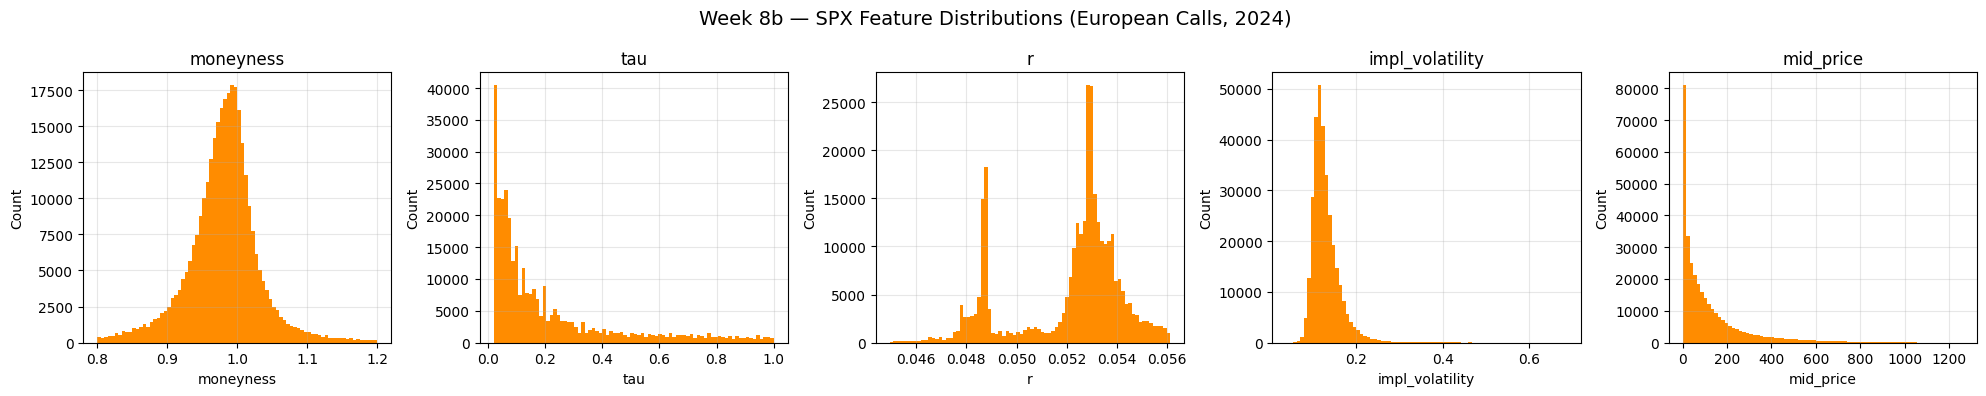

Saved: runs/week8b_optionmetrics_spx_european_2024/20260416-223405/figures/week8b_spx_feature_distributions.png


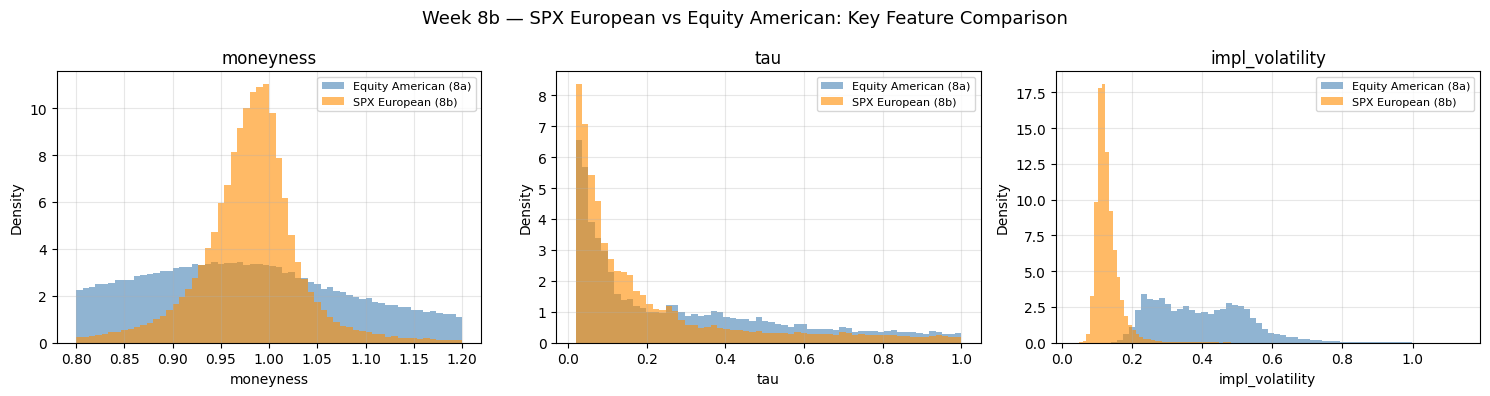

Saved: runs/week8b_optionmetrics_spx_european_2024/20260416-223405/figures/week8b_spx_vs_equity_comparison.png


In [ ]:
# =========================
# CELL 8b.12 — EDA: Feature Distributions and Cross-Pathway Comparison
# =========================

# --- Plot 1: SPX feature histograms ---
feature_cols_spx = ['moneyness', 'tau', 'r', 'impl_volatility', 'mid_price']

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle("Week 8b — SPX Feature Distributions (European Calls, 2024)", fontsize=14)

for i, col in enumerate(feature_cols_spx):
    axes[i].hist(df_spx_final[col], bins=80, color='darkorange', edgecolor='none')
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
hist_path_spx = os.path.join(fig_dir_w8b, "week8b_spx_feature_distributions.png")
plt.savefig(hist_path_spx, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", hist_path_spx)

# --- Plot 2: Side-by-side comparison (SPX European vs Equity American) ---
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle(
    "Week 8b — SPX European vs Equity American: Key Feature Comparison",
    fontsize=13
)

compare_cols = ['moneyness', 'tau', 'impl_volatility']
for i, col in enumerate(compare_cols):
    axes[i].hist(df_final[col],     bins=60, alpha=0.6,
                 color='steelblue',  label='Equity American (8a)', density=True)
    axes[i].hist(df_spx_final[col], bins=60, alpha=0.6,
                 color='darkorange', label='SPX European (8b)',    density=True)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Density")
    axes[i].legend(fontsize=8)
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
compare_path = os.path.join(fig_dir_w8b, "week8b_spx_vs_equity_comparison.png")
plt.savefig(compare_path, dpi=180, bbox_inches="tight")
plt.show()
print("Saved:", compare_path)

In [ ]:
# =========================
# CELL 8b.13 — Save Final SPX Dataset
# =========================

csv_path_w8b = os.path.join(run_dir_w8b, "options_spx_european_2024.csv")
df_spx_final.to_csv(csv_path_w8b, index=False)
print(f"Saved SPX dataset to: {csv_path_w8b}")
print(f"Shape: {df_spx_final.shape}")

save_json(run_dir_w8b, "dataset_summary_spx", {
    "rows":       int(len(df_spx_final)),
    "underlying": "SPX",
    "secid":      SPX_SECID,
    "date_range": {"start": DATE_START, "end": DATE_END},
    "columns":    FINAL_COLS_SPX,
})

Saved SPX dataset to: runs/week8b_optionmetrics_spx_european_2024/20260416-223405/options_spx_european_2024.csv
Shape: (321368, 14)


In [ ]:
# =========================
# CELL 8b.14 — Week 8b Summary
# =========================

summary_text_spx = f"""
WEEK 8b SUMMARY — OptionMetrics Real Data: SPX European Options, 2024

Goal:
Build the SPX European options dataset from OptionMetrics as the second
pathway for MLP training. Contrast with Week 8a American equity options.

Data Sources:
- Option prices:       optionm.opprcd
- Underlying prices:   optionm.secprd
- Risk-free rates:     optionm.zerocd (zero curve, interpolated per row)
- Exercise style:      optionm.opinfd (confirmed European for SPX)

Underlying: SPX (secid = {SPX_SECID})
Date range: {DATE_START} to {DATE_END}

Why bs_price is NOT included (contrast with Week 8a):
- OptionMetrics computes SPX impl_vol by inverting Black-Scholes directly.
- Therefore BS_price(moneyness, tau, r, impl_vol) ≈ mid_price for SPX.
- Adding bs_price would duplicate the label — data leakage, no signal.
- In Week 8a (American), mid_price > bs_price by the early exercise premium.
  That gap is real and learnable, so bs_price is a genuine feature there.

Filtering:
{chr(10).join(f"  {k}: {v:,} rows removed" for k, v in filter_log_spx.items())}
  Rows before: {rows_before_spx:,}
  Rows after:  {rows_after_spx:,}

Final Dataset:
- Shape: {df_spx_final.shape}
- Features: moneyness, tau, r, impl_volatility
- Label:    mid_price (observed SPX European call price)

Pathway Comparison Summary:
  Week 8a — American equity  | features: moneyness, tau, r, impl_vol, bs_price | rows: {len(df_final):,}
  Week 8b — European SPX     | features: moneyness, tau, r, impl_vol            | rows: {len(df_spx_final):,}

Artifacts:
- SPX dataset CSV:               {csv_path_w8b}
- SPX feature distributions:     {hist_path_spx}
- SPX vs equity comparison plot: {compare_path}

Next step:
Week 9 — train PaperMLP on both datasets separately, compare test MSE,
scatter predicted vs actual, interpret differences between the two pathways.
""".strip()

print(summary_text_spx)

summary_path_spx = os.path.join(run_dir_w8b, "week8b_summary.txt")
with open(summary_path_spx, "w") as f:
    f.write(summary_text_spx)

save_json(run_dir_w8b, "week8b_summary", {"summary": summary_text_spx})
print("\nSaved summary to:", summary_path_spx)

WEEK 8b SUMMARY — OptionMetrics Real Data: SPX European Options, 2024

Goal:
Build the SPX European options dataset from OptionMetrics as the second
pathway for MLP training. Contrast with Week 8a American equity options.

Data Sources:
- Option prices:       optionm.opprcd
- Underlying prices:   optionm.secprd
- Risk-free rates:     optionm.zerocd (zero curve, interpolated per row)
- Exercise style:      optionm.opinfd (confirmed European for SPX)

Underlying: SPX (secid = 108105)
Date range: 2024-01-02 to 2024-12-31

Why bs_price is NOT included (contrast with Week 8a):
- OptionMetrics computes SPX impl_vol by inverting Black-Scholes directly.
- Therefore BS_price(moneyness, tau, r, impl_vol) ≈ mid_price for SPX.
- Adding bs_price would duplicate the label — data leakage, no signal.
- In Week 8a (American), mid_price > bs_price by the early exercise premium.
  That gap is real and learnable, so bs_price is a genuine feature there.

Filtering:
  drop_non_european: 0 rows removed
  dro